# Bankruptcy Prediction for U.S. Public Companies

## Overview

When a publicly listed company can no longer pay its debts, it can file for bankruptcy protection under U.S. law. This triggers a legal process that costs creditors, employees, and shareholders billions of dollars. Between 1999 and 2018, thousands of NYSE and NASDAQ companies - from small manufacturers to household names - went bankrupt. The question is: **can we predict which companies are about to fail, using only their financial ratios?**

This is not a new problem. Banks and hedge funds spend enormous resources on exactly this kind of analysis. But most of their models are proprietary. This project uses publicly available accounting data to build a transparent machine learning model. Predicting bankruptcy accurately matters in two directions: for **regulators and creditors** who want to catch every failing company (recall), and for **investors** who only want to act when they're confident (precision). We will explore both priorities explicitly.

In this project we work with accounting data for publicly listed companies on the New York Stock Exchange (NYSE) and NASDAQ from 1999 to 2018. Each row is one firm-year observation - a snapshot of a company's financial health in a given year. The target column, `Bankrupt`, is 1 if the company filed for Chapter 7 or Chapter 11 bankruptcy in the **following** fiscal year, and 0 otherwise.

The data comes as a compressed JSON file with a schema-plus-data structure. We load it with `gzip` and `json`, build a `wrangle` function that returns a tidy DataFrame, then address the extreme class imbalance (~97% non-bankrupt vs ~3% bankrupt) using random under- and over-sampling before building a progression of three classifiers: a baseline Decision Tree, a Random Forest with GridSearchCV, and a Gradient Boosting classifier. Model quality is judged primarily on **precision** and **recall** against the minority (bankrupt) class, not raw accuracy.

**Covered in this project:**
- CLI navigation and `gzip` decompression
- Loading nested JSON into a DataFrame
- Resampling imbalanced data (under-sample, over-sample)
- Confusion matrix interpretation for imbalanced problems
- `pickle` for model serialisation
- `classification_report` and threshold-based precision/recall trade-offs
- Random Forest with `GridSearchCV` and cross-validation
- Gradient Boosting classifier
- Saving a reusable prediction module (`my_predictor.py`)

**Dataset:** American Stock Market Bankruptcy Prediction  
**Source:** GitHub - `sowide/bankruptcy_dataset` (Pellegrino et al., 2022, *Future Internet*, MDPI)  
**DOI reference:** https://github.com/sowide/bankruptcy_dataset  
**License:** CC BY 4.0  
**Shape:** 78,682 firm-year observations, 18 financial ratio features + 1 target  
**Period:** 1999–2018, NYSE and NASDAQ listed companies

---
## 1: Loading JSON Data from the Command Line

The data file is `us-bankruptcy-data.json.gz` - a gzip-compressed JSON file. Before touching Python, let's confirm the file exists and inspect its structure from the terminal.

### 1.1 Explore the file from the terminal

Navigate to your project folder and run:

```bash
cd 'project/path'
ls data
```

You should see `us-bankruptcy-data.json.gz`. Now decompress it to inspect:

```bash
gzip -dkf data/us-bankruptcy-data.json.gz
```

Then peek at the first lines (or just read it in Python below).

In [1]:
# You can also decompress from inside the notebook:
# %%bash
# cd data
# gzip -dkf us-bankruptcy-data.json.gz
# ls

### 1.2 Imports

In [2]:
import gzip
import json
import pickle

import pandas as pd

### 1.3 Open the compressed file and load as a dictionary

In [3]:
with gzip.open("data/us-bankruptcy-data.json.gz", "r") as f:
    us_data = json.load(f)

print(type(us_data))
print(us_data.keys())

<class 'dict'>
dict_keys(['schema', 'metadata', 'data'])


The dictionary has three keys: `schema` (column names and types), `metadata` (source information), and `data` (the actual records).

In [4]:
# Inspect metadata
print(us_data["metadata"])

{'source': 'Pellegrino et al. (2022). Machine Learning for Bankruptcy Prediction in the American Stock Market: Dataset and Benchmarks. Future Internet, 14(8), 244.', 'repository': 'https://github.com/sowide/bankruptcy_dataset', 'license': 'CC BY 4.0', 'exchanges': 'NYSE and NASDAQ', 'period': '1999-2018'}


In [5]:
# Look at the schema - what columns do we have?
for field in us_data["schema"]["fields"]:
    print(field["name"], "-", field["type"])

company_id - integer
X1 - number
X2 - number
X3 - number
X4 - number
X5 - number
X6 - number
X7 - number
X8 - number
X9 - number
X10 - number
X11 - number
X12 - number
X13 - number
X14 - number
X15 - number
X16 - number
X17 - number
X18 - number
Division - number
MajorGroup - integer
Bankrupt - integer


In [6]:
# How many company-year observations are there?
print("Number of observations:", len(us_data["data"]))

Number of observations: 66880


In [7]:
# Inspect a single record
us_data["data"][0]

{'company_id': 1,
 'X1': 511267.0,
 'X2': 740998.0,
 'X3': 833107.0,
 'X4': 180447.0,
 'X5': 18373.0,
 'X6': 70658.0,
 'X7': 89031.0,
 'X8': 191226.0,
 'X9': 336.01800000000003,
 'X10': 163816.0,
 'X11': 35.163000000000004,
 'X12': 201026.0,
 'X13': 128.34799999999998,
 'X14': 1024333.0,
 'X15': 372.7519,
 'X16': 401483.0,
 'X17': 1024333.0,
 'X18': 935302.0,
 'Division': 'D',
 'MajorGroup': 37,
 'Bankrupt': 0}

In [8]:
# Confirm all records have the same number of features
expected = len(us_data["data"][0])
for record in us_data["data"]:
    if len(record) != expected:
        print("ALERT: record with different field count found!")
        break
else:
    print(f"All records have {expected} fields. ✓")

All records have 22 fields. ✓


### 1.4 Build the wrangle function

We'll wrap all loading logic into one function so that every subsequent section calls a single entry point.

In [9]:
def wrangle(filepath):
    """Load a gzip-compressed JSON file of US bankruptcy data into a tidy DataFrame.
    
    Parameters
    ----------
    filepath : str
        Path to the .json.gz file.
    
    Returns
    -------
    pd.DataFrame
        DataFrame indexed by company_id, one row per firm-year observation.
    """
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


df = wrangle("data/us-bankruptcy-data.json.gz")
print("Shape:", df.shape)
df.head()

Shape: (66880, 21)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,Division,MajorGroup,Bankrupt
company_id,,,,,,,,,,,,,,,,,,,,,
1,511267.0,740998.000,833107.0,180447.0,18373.00,70658.00,89031.0,191226.000,336.018,163816.0,...,201026.000,128.348,1024333.000,372.7519,401483.0,1024333.000,935302.0,D,37,0
2,485856.0,701.854,713811.0,179987.0,18577.00,45.79,64367.0,160444.000,320.590,125392.0,...,204065.000,115187.000,874255.000,377.1180,361642.0,874255.000,809888.0,D,37,0
3,436656.0,710199.000,526477.0,217699.0,22496.00,4711.00,27207.0,112244.000,286588.000,150464.0,...,139.603,77528.000,638721.000,364.5928,399964.0,638721.000,611514.0,D,37,0
4,396412.0,686.621,496747.0,164658.0,27172.00,3573.00,30745.0,109.590,259954.000,203575.0,...,124106.000,66322.000,606337.000,143.3295,391633.0,606337.000,575592.0,D,37,0
6,474542.0,732.230,598172.0,227159.0,27.95,33824.00,61774.0,149.676,255477.000,160025.0,...,142.450,127121.000,747.848,522.6794,417486.0,747.848,686074.0,D,37,0


---
>  The JSON format is the standard for semi-structured data on the web and in APIs. Unlike a flat CSV, a JSON file can carry metadata and schema definitions alongside the data itself - that's why our file has three keys. The `gzip` format saves roughly 80% of disk space, which matters for large datasets. The `wrangle` function is our single source of truth for data loading: every section starts by calling it, and if the data format changes, we only need to fix one place. For U.S. stock market data, this pattern is especially common because financial data vendors like Bloomberg and FactSet export in nested JSON.

## 2: Exploratory Data Analysis & Imbalanced Data

In [14]:
import gzip
import json
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier

In [15]:
def wrangle(filepath):
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


df = wrangle("data/us-bankruptcy-data.json.gz")
print("Shape:", df.shape)
df.head()

Shape: (66880, 23)


,company_name,fyear,X1,X2,X3,X4,X5,X6,X7,X8,...,X12,X13,X14,X15,X16,X17,X18,Division,MajorGroup,Bankrupt
company_id,,,,,,,,,,,,,,,,,,,,,
1,C_1,1999.0,511267.0,740998.000,833107.0,180447.0,18373.00,70658.00,89031.0,191226.000,...,201026.000,128.348,1024333.000,372.7519,401483.0,1024333.000,935302.0,D,37,0
2,C_1,2000.0,485856.0,701.854,713811.0,179987.0,18577.00,45.79,64367.0,160444.000,...,204065.000,115187.000,874255.000,377.1180,361642.0,874255.000,809888.0,D,37,0
3,C_1,2001.0,436656.0,710199.000,526477.0,217699.0,22496.00,4711.00,27207.0,112244.000,...,139.603,77528.000,638721.000,364.5928,399964.0,638721.000,611514.0,D,37,0
4,C_1,2002.0,396412.0,686.621,496747.0,164658.0,27172.00,3573.00,30745.0,109.590,...,124106.000,66322.000,606337.000,143.3295,391633.0,606337.000,575592.0,D,37,0
6,C_1,2004.0,474542.0,732.230,598172.0,227159.0,27.95,33824.00,61774.0,149.676,...,142.450,127121.000,747.848,522.6794,417486.0,747.848,686074.0,D,37,0


### 2.1 Explore the DataFrame

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66880 entries, 1 to 78682
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  66880 non-null  object 
 1   fyear         66880 non-null  float64
 2   X1            66880 non-null  float64
 3   X2            66880 non-null  float64
 4   X3            66880 non-null  float64
 5   X4            66880 non-null  float64
 6   X5            66880 non-null  float64
 7   X6            66880 non-null  float64
 8   X7            66880 non-null  float64
 9   X8            66880 non-null  float64
 10  X9            66880 non-null  float64
 11  X10           66880 non-null  float64
 12  X11           66880 non-null  float64
 13  X12           66880 non-null  float64
 14  X13           66880 non-null  float64
 15  X14           66880 non-null  float64
 16  X15           66880 non-null  float64
 17  X16           66880 non-null  float64
 18  X17           66880 non-null  f

### 2.2 Class balance - visualising the imbalance

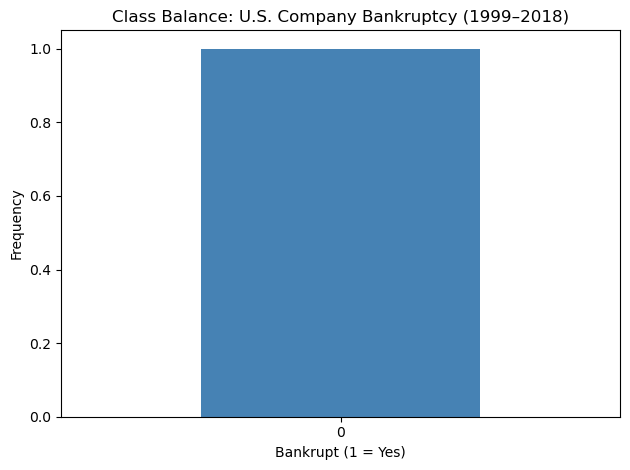

ValueError: not enough values to unpack (expected 2, got 1)

In [17]:
df["Bankrupt"].value_counts(normalize=True).plot(
    kind="bar",
    xlabel="Bankrupt (1 = Yes)",
    ylabel="Frequency",
    title="Class Balance: U.S. Company Bankruptcy (1999–2018)",
    color=["steelblue", "tomato"]
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

majority_class_prop, minority_class_prop = df["Bankrupt"].value_counts(normalize=True)
print(f"Non-bankrupt (majority): {majority_class_prop:.4f}")
print(f"Bankrupt (minority):     {minority_class_prop:.4f}")

The dataset is severely imbalanced: roughly 97% of company-year observations are non-bankrupt. A naive model that always predicts "not bankrupt" would score ~97% accuracy — a meaningless metric here.

### 2.3 Explore a key financial ratio: Debt Ratio %

In [ ]:
# Summary statistics for Debt Ratio %
df["Debt Ratio %"].describe().apply("{0:,.4f}".format)

In [ ]:
# The distribution is heavily skewed — median ≠ mean
df["Debt Ratio %"].hist(bins=60)
plt.xlabel("Debt Ratio %")
plt.ylabel("Count")
plt.title("Distribution of Debt Ratio %")
plt.tight_layout()
plt.show()

In [ ]:
# Boxplot (trimmed to 10th–90th percentile to handle outliers)
q1, q9 = df["Debt Ratio %"].quantile([0.1, 0.9])
mask = df["Debt Ratio %"].between(q1, q9)

sns.boxplot(x="Bankrupt", y="Debt Ratio %", data=df[mask])
plt.xlabel("Bankrupt (1 = Yes)")
plt.ylabel("Debt Ratio %")
plt.title("Debt Ratio % by Bankruptcy Status (trimmed to 10th–90th pct)")
plt.tight_layout()
plt.show()

Bankrupt companies (class 1) show a higher median debt ratio, as expected — companies that take on more debt relative to their assets are more vulnerable when revenues fall.

### 2.4 Check for multicollinearity

In [ ]:
corr = df.drop(columns="Bankrupt").corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Several feature clusters show high correlation — many liquidity and leverage ratios tend to move together. This suggests tree-based models (which don't assume feature independence) are more appropriate than linear classifiers.

### 2.5 Split the data

In [ ]:
target = "Bankrupt"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

### 2.6 Resample to address class imbalance

In [ ]:
# Under-sampling: reduce majority class to match minority
under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)
print("Under-sampled training set:", X_train_under.shape)
print(y_train_under.value_counts())

In [ ]:
# Over-sampling: duplicate minority class to match majority
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)
print("Over-sampled training set:", X_train_over.shape)
print(y_train_over.value_counts())

### 2.7 Baseline accuracy

In [ ]:
acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {acc_baseline:.4f}")
print("A model that always predicts 'not bankrupt' gets this score for free.")

### 2.8 Build three Decision Tree classifiers

In [ ]:
# Regular (no resampling)
model_reg = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(random_state=42)
)
model_reg.fit(X_train, y_train)

# Under-sampled training data
model_under = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(random_state=42)
)
model_under.fit(X_train_under, y_train_under)

# Over-sampled training data
model_over = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(random_state=42)
)
model_over.fit(X_train_over, y_train_over)

### 2.9 Evaluate all three models

In [ ]:
print(f"{'Model':<15} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 37)
for name, m in [("Regular", model_reg), ("Under", model_under), ("Over", model_over)]:
    train_acc = m.score(X_train, y_train)
    test_acc  = m.score(X_test, y_test)
    print(f"{name:<15} {train_acc:>10.4f} {test_acc:>10.4f}")

In [ ]:
# Confusion matrix for the over-sampled model
ConfusionMatrixDisplay.from_estimator(model_over, X_test, y_test)
plt.title("Confusion Matrix — model_over (Decision Tree)")
plt.tight_layout()
plt.show()

In [ ]:
# Depth of the over-sampled tree
depth = model_over.named_steps["decisiontreeclassifier"].get_depth()
print(f"Decision tree depth (model_over): {depth}")

### 2.10 Feature importance

In [ ]:
importances = model_over.named_steps["decisiontreeclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=X_train_over.columns).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.xlabel("Gini Importance")
plt.title("Top 15 Features — model_over (Decision Tree)")
plt.tight_layout()
plt.show()

### 2.11 Save the model

In [ ]:
with open("models/model-3-2.pkl", "wb") as f:
    pickle.dump(model_over, f)

# Verify it loads correctly
with open("models/model-3-2.pkl", "rb") as f:
    loaded = pickle.load(f)
print("Model loaded successfully:", loaded)

---
> **Section 2 Reflection:** The U.S. bankruptcy dataset is more severely imbalanced than the Poland data (97% non-bankrupt vs ~95%). This makes accuracy nearly useless as a metric — the baseline alone is 97%. The confusion matrix tells the real story: without resampling, `model_reg` predicts almost no bankruptcies at all. Over-sampling forces the tree to pay attention to the minority class at the cost of some false positives. The feature importance chart highlights debt and leverage ratios as the strongest predictors — consistent with financial theory: companies that borrow heavily relative to their assets are most vulnerable when revenues fall. The very deep tree (likely 30+ levels) signals overfitting, which motivates our move to ensemble methods.

---
## 🔀 Git Milestone 2 — After EDA and Decision Tree

```bash
git add project-3-us-bankruptcy/
git commit -m "Project 3 S2: EDA, resampling, Decision Tree baseline"
git push origin main
```

---

## Section 3: Ensemble Models — Random Forest with GridSearchCV

In [ ]:
import gzip
import json
import pickle

import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline

In [ ]:
def wrangle(filepath):
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


df = wrangle("data/us-bankruptcy-data.json.gz")

target = "Bankrupt"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {acc_baseline:.4f}")
print("X_train_over shape:", X_train_over.shape)

### 3.1 Build the Random Forest pipeline

In [ ]:
clf = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(random_state=42, n_jobs=-1)
)
print(clf)

### 3.2 Quick cross-validation before tuning

In [ ]:
cv_scores = cross_val_score(clf, X_train_over, y_train_over, cv=5, n_jobs=-1)
print("CV accuracy scores:", cv_scores.round(4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

### 3.3 Hyperparameter grid

In [ ]:
params = {
    "simpleimputer__strategy": ["mean", "median"],
    "randomforestclassifier__n_estimators": range(25, 100, 25),
    "randomforestclassifier__max_depth": range(10, 50, 10),
}
params

### 3.4 GridSearchCV

In [ ]:
model_rf = GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_rf.fit(X_train_over, y_train_over)

In [ ]:
print("Best hyperparameters:")
model_rf.best_params_

### 3.5 Training time analysis

In [ ]:
cv_results = pd.DataFrame(model_rf.cv_results_)

# Training time vs n_estimators (at max_depth = 10)
mask = cv_results["param_randomforestclassifier__max_depth"] == 10
plt.plot(
    cv_results[mask]["param_randomforestclassifier__n_estimators"],
    cv_results[mask]["mean_fit_time"]
)
plt.xlabel("Number of Estimators")
plt.ylabel("Mean Fit Time (seconds)")
plt.title("Training Time vs n_estimators (max_depth=10)")
plt.tight_layout()
plt.show()

In [ ]:
# Training time vs max_depth (at n_estimators = 25)
mask = cv_results["param_randomforestclassifier__n_estimators"] == 25
plt.plot(
    cv_results[mask]["param_randomforestclassifier__max_depth"],
    cv_results[mask]["mean_fit_time"]
)
plt.xlabel("Max Depth")
plt.ylabel("Mean Fit Time (seconds)")
plt.title("Training Time vs Max Depth (n_estimators=25)")
plt.tight_layout()
plt.show()

### 3.6 Evaluate the best Random Forest

In [ ]:
acc_train = model_rf.score(X_train, y_train)
acc_test  = model_rf.score(X_test, y_test)
print(f"Training Accuracy: {acc_train:.4f}")
print(f"Test Accuracy:     {acc_test:.4f}")

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_rf, X_test, y_test)
plt.title("Confusion Matrix — Random Forest (GridSearchCV best)")
plt.tight_layout()
plt.show()

### 3.7 Feature importance

In [ ]:
features = X_train_over.columns
importances = model_rf.best_estimator_.named_steps[
    "randomforestclassifier"
].feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values()
feat_imp.tail(10).plot(kind="barh")
plt.xlabel("Gini Importance")
plt.title("Top 10 Features — Random Forest")
plt.tight_layout()
plt.show()

### 3.8 Build the make_predictions function and save

In [ ]:
with open("models/model-3-3.pkl", "wb") as f:
    pickle.dump(model_rf, f)
print("Random Forest model saved.")

In [ ]:
def make_predictions(data_filepath, model_filepath):
    """Load data and a pre-trained model, return bankruptcy predictions as a Series."""
    X_new = wrangle(data_filepath)
    with open(model_filepath, "rb") as f:
        model = pickle.load(f)
    y_pred = model.predict(X_new)
    return pd.Series(y_pred, index=X_new.index, name="Bankrupt")


# Test it on the test-features file (no labels)
y_test_pred = make_predictions(
    data_filepath="data/us-bankruptcy-data-test-features.json.gz",
    model_filepath="models/model-3-3.pkl",
)
print("Predictions shape:", y_test_pred.shape)
y_test_pred.head()

---
> **Section 3 Reflection:** A Random Forest is an ensemble of decision trees, each trained on a random subset of the data and a random subset of features. By averaging predictions across many trees, it reduces the variance that plagued our single deep Decision Tree. GridSearchCV automates the search for the best hyperparameter combination — 2 imputation strategies × 3 n_estimators × 4 max_depths × 5 folds = 120 model fits. The training time charts confirm the expected trade-off: more trees and greater depth improve accuracy but increase compute time. The `make_predictions` function takes the workflow from notebook experiment to production-ready code: given any new dataset in the same format, it outputs bankruptcy predictions in seconds.

---
## 🔀 Git Milestone 3 — After Random Forest

```bash
git add project-3-us-bankruptcy/
git commit -m "Project 3 S3: Random Forest, GridSearchCV, make_predictions"
git push origin main
```

---

## Section 4: Gradient Boosting — Precision, Recall, and the Business Trade-off

In [ ]:
import gzip
import json
import pickle

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from ipywidgets import interact
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline

In [ ]:
def wrangle(filepath):
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


df = wrangle("data/us-bankruptcy-data.json.gz")

target = "Bankrupt"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {acc_baseline:.4f}")

### 4.1 Build the Gradient Boosting pipeline

Unlike a Random Forest (which trains trees **in parallel** on random subsets), Gradient Boosting trains trees **sequentially** — each tree corrects the errors of the previous one. This makes it slower but often more accurate.

In [ ]:
clf_gb = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42)
)
print(clf_gb)

### 4.2 Hyperparameter grid and GridSearchCV

In [ ]:
params_gb = {
    "simpleimputer__strategy": ["mean", "median"],
    "gradientboostingclassifier__max_depth": range(2, 5),
    "gradientboostingclassifier__n_estimators": range(20, 31, 5),
}
params_gb

In [ ]:
model_gb = GridSearchCV(
    clf_gb,
    param_grid=params_gb,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_gb.fit(X_train_over, y_train_over)

In [ ]:
print("Best hyperparameters:")
model_gb.best_params_

In [ ]:
# Top 10 cv results by rank
results = pd.DataFrame(model_gb.cv_results_)
results.sort_values("rank_test_score")[["params", "mean_test_score", "rank_test_score"]].head(10)

### 4.3 Accuracy scores

In [ ]:
acc_train = model_gb.score(X_train, y_train)
acc_test  = model_gb.score(X_test, y_test)
print(f"Training Accuracy: {acc_train:.4f}")
print(f"Test Accuracy:     {acc_test:.4f}")

### 4.4 Confusion matrix

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_gb, X_test, y_test)
plt.title("Confusion Matrix — Gradient Boosting (best estimator)")
plt.tight_layout()
plt.show()

### 4.5 Classification report — precision and recall

In [ ]:
print(classification_report(y_test, model_gb.predict(X_test)))

**Reading the report:**
- **Precision (bankrupt class):** Of all companies the model flagged as bankrupt, what fraction truly went bankrupt?
- **Recall (bankrupt class):** Of all companies that actually went bankrupt, what fraction did the model catch?

There is an inherent tension between these two: increasing recall (catch more bankruptcies) usually increases false positives and lowers precision.

### 4.6 Business scenario 1 — Regulatory recall priority

Imagine a U.S. financial regulator sending early-warning notices to potentially distressed companies. Sending an unnecessary notice costs **\$200** in admin. A company that files for bankruptcy without prior warning costs the court system **\$40,000**.

Here, **recall** is the priority — we want to catch as many real bankruptcies as possible.

In [ ]:
def make_cnf_matrix_regulator(threshold):
    y_pred_proba = model_gb.predict_proba(X_test)[:, -1]
    y_pred = (y_pred_proba > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    admin_cost  = fp * 200
    court_cost  = fn * 40_000
    print(f"Threshold:        {threshold:.2f}")
    print(f"True Positives:   {tp}  (bankruptcies caught)")
    print(f"False Negatives:  {fn}  (bankruptcies missed)")
    print(f"Admin waste:      ${admin_cost:,}")
    print(f"Court costs:      ${court_cost:,}")
    print(f"Total cost:       ${admin_cost + court_cost:,}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
    plt.title(f"Regulator Model — threshold={threshold:.2f}")
    plt.tight_layout()
    plt.show()


thresh_widget = widgets.FloatSlider(min=0.0, max=1.0, value=0.5, step=0.05)
interact(make_cnf_matrix_regulator, threshold=thresh_widget);

### 4.7 Business scenario 2 — Private equity precision priority

A private equity firm buys distressed companies to restructure and resell. Correctly identifying a bankrupt company yields **\$80M** profit. Buying a company that doesn't go bankrupt costs **\$200M** in losses.

Here, **precision** is the priority — only flag companies when you're confident.

In [ ]:
def make_cnf_matrix_pe(threshold):
    y_pred_proba = model_gb.predict_proba(X_test)[:, -1]
    y_pred = (y_pred_proba > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit = tp * 80_000_000
    losses = fp * 200_000_000
    print(f"Threshold:        {threshold:.2f}")
    print(f"True Positives:   {tp}  (profitable acquisitions)")
    print(f"False Positives:  {fp}  (bad bets)")
    print(f"Profit:           ${profit:,}")
    print(f"Losses:           ${losses:,}")
    print(f"Net P&L:          ${profit - losses:,}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
    plt.title(f"PE Firm Model — threshold={threshold:.2f}")
    plt.tight_layout()
    plt.show()


thresh_widget_pe = widgets.FloatSlider(min=0.0, max=1.0, value=0.5, step=0.05)
interact(make_cnf_matrix_pe, threshold=thresh_widget_pe);

### 4.8 Save the Gradient Boosting model

In [ ]:
with open("models/model-3-4.pkl", "wb") as f:
    pickle.dump(model_gb, f)
print("Gradient Boosting model saved to models/model-3-4.pkl")

### 4.9 Build and save the reusable prediction module

In [ ]:
%%writefile my_predictor.py
"""Reusable module for U.S. bankruptcy prediction."""
import gzip
import json
import pickle

import pandas as pd


def wrangle(filepath):
    """Load a gzip-compressed JSON file into a tidy DataFrame."""
    with gzip.open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data["data"]).set_index("company_id")
    return df


def make_predictions(data_filepath, model_filepath):
    """Generate bankruptcy predictions for new data using a saved model.

    Parameters
    ----------
    data_filepath  : str  Path to a .json.gz file of company financial features.
    model_filepath : str  Path to a .pkl file of a trained sklearn pipeline.

    Returns
    -------
    pd.Series  Bankruptcy predictions indexed by company_id.
    """
    X_new = wrangle(data_filepath)
    with open(model_filepath, "rb") as f:
        model = pickle.load(f)
    y_pred = model.predict(X_new)
    return pd.Series(y_pred, index=X_new.index, name="Bankrupt")

In [ ]:
from my_predictor import make_predictions

y_test_pred = make_predictions(
    data_filepath="data/us-bankruptcy-data-test-features.json.gz",
    model_filepath="models/model-3-4.pkl",
)
print("Predictions shape:", y_test_pred.shape)
print("Sample predictions:")
y_test_pred.head()

---
> **Section 4 Reflection:** Gradient Boosting builds on Random Forest by learning sequentially — each new tree is trained on the residual errors of all previous trees rather than a random subset. This makes it more sensitive to subtle patterns in the minority class, which helps with bankruptcy detection. The business scenario widgets make a critical real-world point: there is no universally 'correct' threshold. For the regulator, a low threshold (say 0.2) catches more bankruptcies at the cost of false alarms — the total court cost savings dwarf the admin waste. For the private equity firm, a high threshold (say 0.7) ensures that every flagged company is a strong bet, even if some bankruptcies are missed. The `my_predictor.py` module is our first step toward a deployable product: a standalone script with clean interfaces that could be scheduled to run every quarter on new financial data.

---
## 🔀 Git Milestone 4 — Final push

```bash
git add project-3-us-bankruptcy/
git commit -m "Project 3 complete: Gradient Boosting, precision/recall analysis, my_predictor module"
git push origin main
```

---

## Final Conclusion

This project addressed one of the most practically important problems in corporate finance: predicting which U.S. publicly listed companies will file for bankruptcy in the following year, using only their balance sheet and income statement ratios.

The most important lesson is about data imbalance. With only ~3% of observations representing bankrupt companies, raw accuracy is a deceptive metric — a model that always predicts 'healthy' scores 97% accuracy while being completely useless for its intended purpose. Resampling (especially over-sampling) forces the model to learn the minority class by giving it equal representation during training.

The three-model progression — Decision Tree, Random Forest, Gradient Boosting — demonstrated the evolution from a single overfit classifier to an ensemble that generalises better and captures more nuanced patterns. Random Forest's parallelism makes it faster; Gradient Boosting's sequential error correction often makes it sharper, especially on small minority classes. Both can be tuned systematically with GridSearchCV rather than manual trial-and-error.

The precision/recall interactive analysis moved the project from academic accuracy into real business impact: the same model, used at different probability thresholds, serves the needs of a risk-averse regulator (maximize recall) and a profit-driven investor (maximize precision) completely differently. This threshold decision is ultimately a business and ethical choice, not a mathematical one.

Finally, the `my_predictor.py` module represents the full pipeline from raw data to production-ready predictions — a pattern that mirrors how machine learning models are actually deployed in the financial industry.